# House Price Prediction - Exploratory Data Analysis


## Problem Statement

The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a Machine Learning regression model that predicts the price of a house using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was built.

Students are required to analyze the dataset, perform data preprocessing, apply feature engineering techniques, train multiple regression models, and evaluate their performance to identify the best model for predicting house prices.

## Objectives
- Understand and explore the housing dataset.
- Perform data preprocessing including handling missing values, duplicates, and outliers.
- Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the data.
- Apply encoding, log transformation, and feature scaling where necessary.
- Train multiple regression algorithms to predict house prices.
- Evaluate and compare model performance using appropriate evaluation metrics.
- Perform cross-validation and hyperparameter tuning to improve model performance.
- Select the best-performing model for final predictions.

## **Import Libraries**

In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Dataset**

In [335]:
data = pd.read_csv('/content/house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


## **Data Description**
The dataset contains information about residential properties. It includes details related to house size, number of rooms, lot size, garage, neighborhood quality, year built, and the house price. This dataset helps analyze the key factors that influence house prices.

**Square_Footage** – Total square footage of the house.

**Num_Bedrooms** – Number of bedrooms in the house.

**Num_Bathrooms** – Number of bathrooms in the house.

**Year_Built** – Year in which the house was built.

**Lot_Size** – Size of the lot on which the house is built.

**Garage_Size** – Size of the garage (0 = No garage).

**Neighborhood_Quality** – Quality rating of the neighborhood (1 to 10 scale).

**House_Price** – Price of the house (Target Variable).

## **Basic Checks**

In [336]:
# check number of rows and columns
data.shape

(1000, 8)

In [337]:
# print first 5 rows
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [338]:
# print last 5 rows
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [339]:
# check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [340]:
# check data types
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [341]:
# print all column names
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [342]:
# select numerical columns
num_data = data.select_dtypes(include=['int64', 'float64'])
num_data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [343]:
# statistical summary
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [344]:
# describe all columns
data.describe(include='all')

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## **Data Preprocessing**

**Check for Duplicates**

In [345]:
data.duplicated().sum()

np.int64(0)

Clearly it shows **no duplicate** records in the dataset.

**Check for Missing Values**

In [346]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


The dataset has **no missing values**. All columns are complete and ready for analysis.

**No missing value handling required** since the dataset is clean.

## **Explore Data Using Visualization**

# Univariate Analysis



**Distribution of House Price**

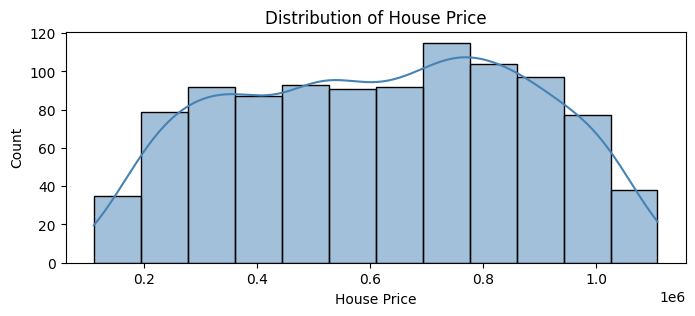

In [347]:
plt.figure(figsize=(8, 3))
sns.histplot(data, x='House_Price', kde=True, color='steelblue')
plt.title('Distribution of House Price')
plt.xlabel('House Price')
plt.ylabel('Count')
plt.show()

**Insight:**

The distribution of House Price is approximately **normal** with most houses priced between 4,00,000 and 8,00,000. Very few houses fall at extreme price ranges.

**Distribution of Square Footage**

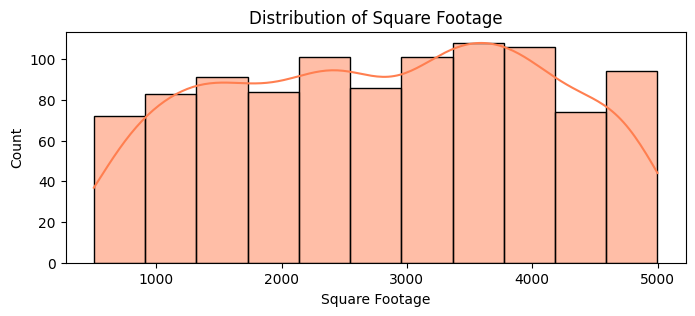

In [348]:
plt.figure(figsize=(8, 3))
sns.histplot(data, x='Square_Footage', kde=True, color='coral')
plt.title('Distribution of Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Count')
plt.show()

**Insight:**

Square footage is fairly uniformly distributed between 500 and 5000, indicating the dataset contains a wide variety of house sizes.

**Distribution of Number of Bedrooms**

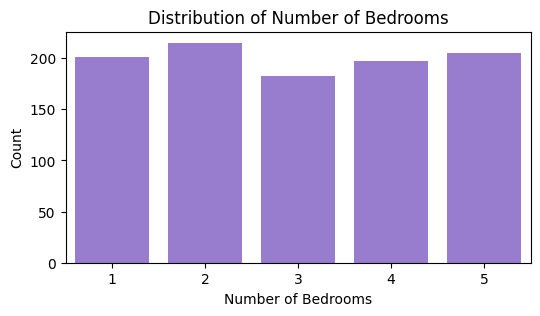

In [349]:
plt.figure(figsize=(6, 3))
sns.countplot(data=data, x='Num_Bedrooms', color='mediumpurple')
plt.title('Distribution of Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

**Insight:**

Most houses have 2 to 4 bedrooms. Houses with 1 or 5 bedrooms are relatively rare in the dataset.

**Distribution of Number of Bathrooms**

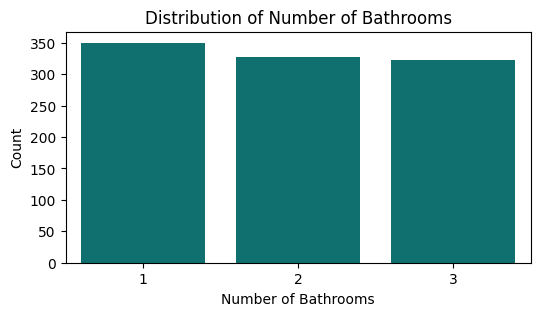

In [350]:
plt.figure(figsize=(6, 3))
sns.countplot(data=data, x='Num_Bathrooms', color='teal')
plt.title('Distribution of Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

**Insight:**

The number of bathrooms ranges from 1 to 3. Most houses have 1 or 2 bathrooms.

**Distribution of Neighborhood Quality**

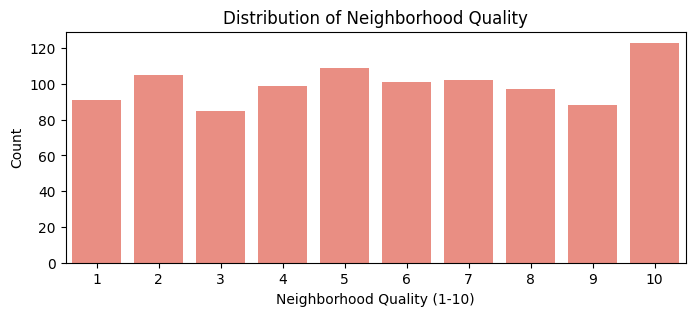

In [351]:
plt.figure(figsize=(8, 3))
sns.countplot(data=data, x='Neighborhood_Quality', color='salmon')
plt.title('Distribution of Neighborhood Quality')
plt.xlabel('Neighborhood Quality (1-10)')
plt.ylabel('Count')
plt.show()

**Insight:**

Neighborhood quality is evenly spread across all ratings from 1 to 10, indicating a diverse mix of localities in the dataset.

**Distribution of Year Built**

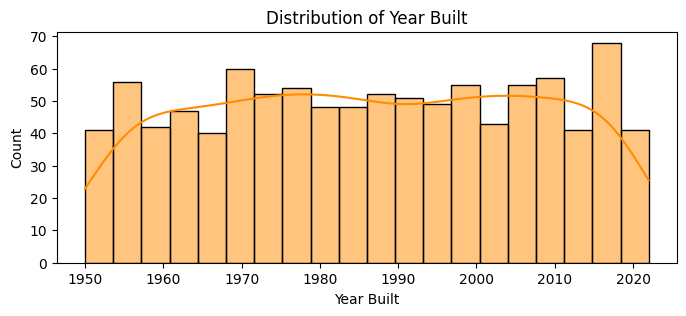

In [352]:
plt.figure(figsize=(8, 3))
sns.histplot(data, x='Year_Built', kde=True, color='darkorange', bins=20)
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')
plt.show()

**Insight:**

Houses in the dataset were built across a wide range of years. There is a relatively even spread, indicating the dataset represents both old and newly built houses.

**Distribution of Lot Size**

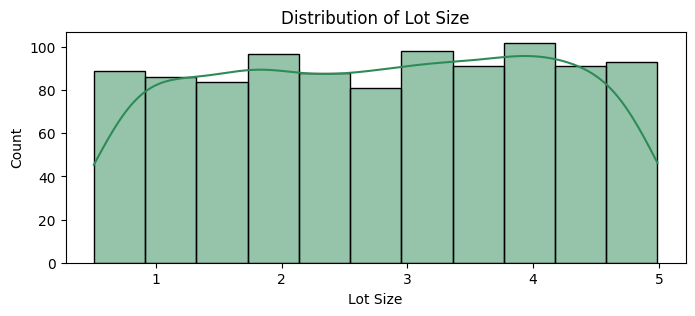

In [353]:
plt.figure(figsize=(8, 3))
sns.histplot(data, x='Lot_Size', kde=True, color='seagreen')
plt.title('Distribution of Lot Size')
plt.xlabel('Lot Size')
plt.ylabel('Count')
plt.show()

**Insight:**

Lot size appears to follow a normal distribution. Most houses have lot sizes clustered around the middle range.

**Distribution of Garage Size**

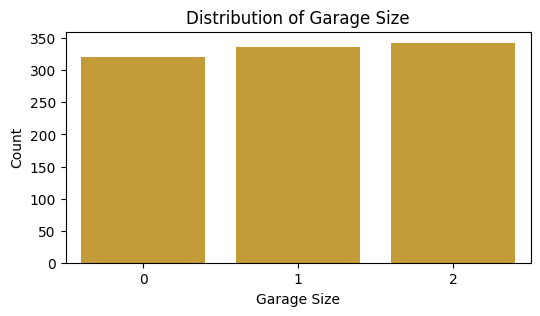

In [354]:
plt.figure(figsize=(6, 3))
sns.countplot(data=data, x='Garage_Size', color='goldenrod')
plt.title('Distribution of Garage Size')
plt.xlabel('Garage Size')
plt.ylabel('Count')
plt.show()

**Insight:**

A significant number of houses have no garage (0). Houses with garages are split fairly evenly among size 1, 2, and 3.

# **Bivariate Analysis**

Bivariate analysis means analyzing the relationship between two variables.

**How does Square Footage impact House Price?**

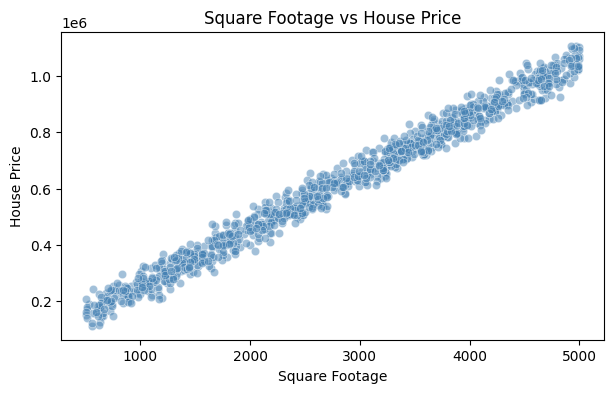

In [355]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data, x='Square_Footage', y='House_Price', color='steelblue', alpha=0.5)
plt.title('Square Footage vs House Price')
plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.show()

**Insight:**

There is a clear **positive relationship** between Square Footage and House Price. As the size of the house increases, the price increases proportionally.

**How does Neighborhood Quality impact House Price?**

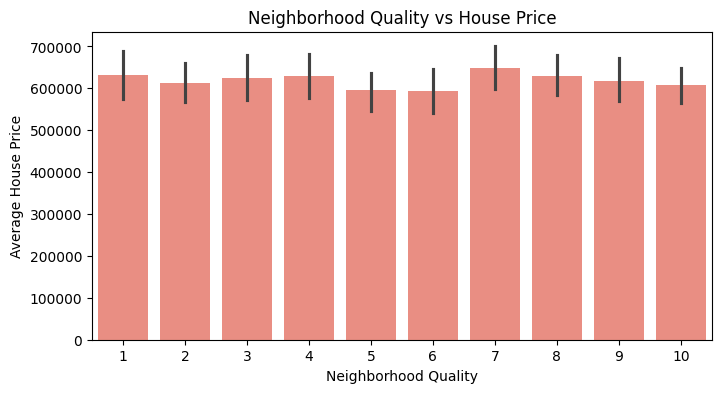

In [356]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='Neighborhood_Quality', y='House_Price', color='salmon')
plt.title('Neighborhood Quality vs House Price')
plt.xlabel('Neighborhood Quality')
plt.ylabel('Average House Price')
plt.show()

**Insight:**

Houses in higher quality neighborhoods have significantly higher average prices. **Neighborhood Quality** is a strong predictor of House Price.

**How does Number of Bedrooms impact House Price?**

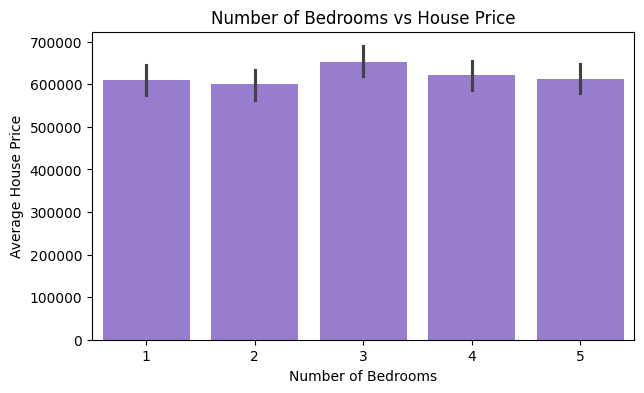

In [357]:
plt.figure(figsize=(7, 4))
sns.barplot(data=data, x='Num_Bedrooms', y='House_Price', color='mediumpurple')
plt.title('Number of Bedrooms vs House Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average House Price')
plt.show()

**Insight:**

Houses with more bedrooms generally have a higher price. This shows a positive relationship between number of bedrooms and house price.

**How does Number of Bathrooms impact House Price?**

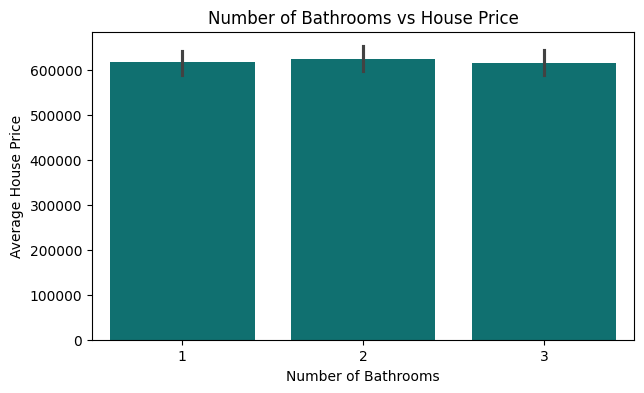

In [358]:
plt.figure(figsize=(7, 4))
sns.barplot(data=data, x='Num_Bathrooms', y='House_Price', color='teal')
plt.title('Number of Bathrooms vs House Price')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average House Price')
plt.show()

**Insight:**

Houses with more bathrooms tend to have a higher average price, indicating bathrooms positively contribute to house value.

**How does Garage Size impact House Price?**

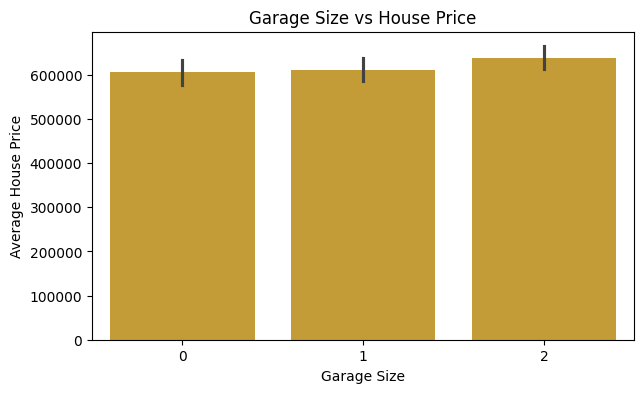

In [359]:
plt.figure(figsize=(7, 4))
sns.barplot(data=data, x='Garage_Size', y='House_Price', color='goldenrod')
plt.title('Garage Size vs House Price')
plt.xlabel('Garage Size')
plt.ylabel('Average House Price')
plt.show()

**Insight:**

Houses with larger garages tend to have a higher price. Houses without a garage (0) have the lowest average price.

**How does Year Built relate to House Price?**

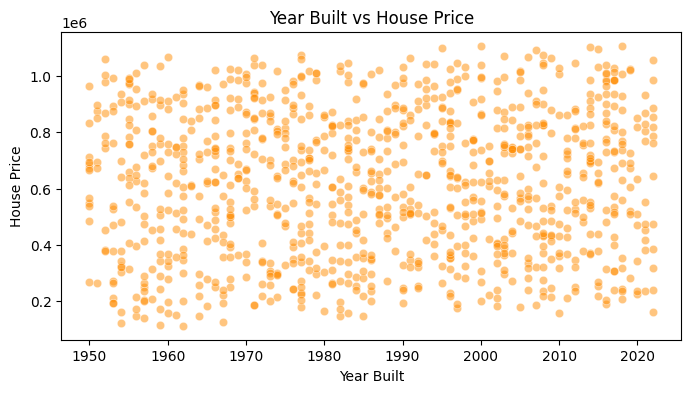

In [360]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=data, x='Year_Built', y='House_Price', color='darkorange', alpha=0.5)
plt.title('Year Built vs House Price')
plt.xlabel('Year Built')
plt.ylabel('House Price')
plt.show()

**Insight:**

There is no strong linear relationship between Year Built and House Price. Houses built in both older and recent years show a wide range of prices.

**Correlation Heatmap**

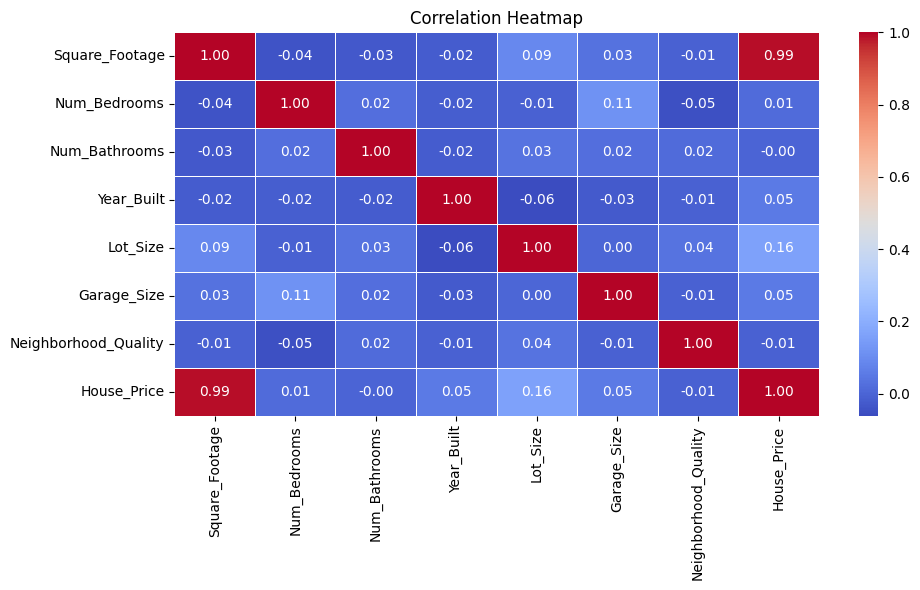

In [361]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:**

- **Square_Footage** has the highest positive correlation with House Price.
- **Neighborhood_Quality** and **Num_Bedrooms** also show strong positive correlations.
- **Year_Built** and **Garage_Size** show relatively weaker correlations with House Price.

# Multivariate Analysis
Multivariate analysis means analyzing more than two variables together.

**Square Footage, Neighborhood Quality and House Price**

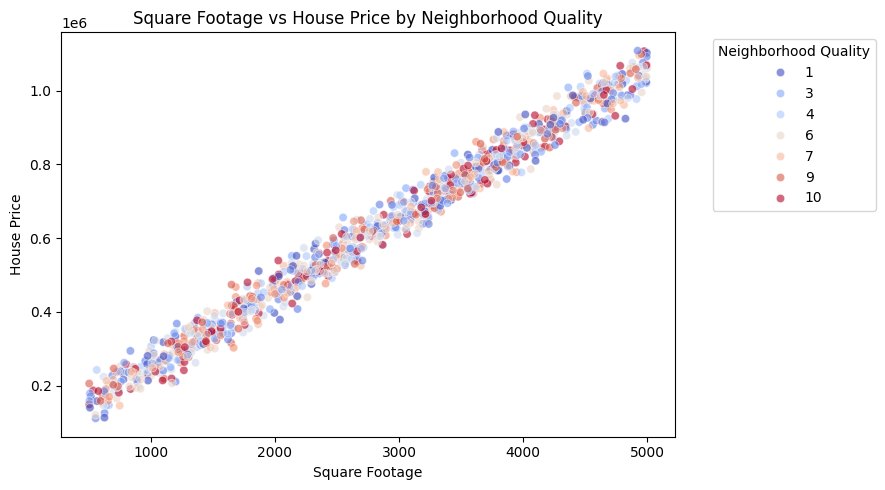

In [362]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=data, x='Square_Footage', y='House_Price',
                hue='Neighborhood_Quality', palette='coolwarm', alpha=0.6)
plt.title('Square Footage vs House Price by Neighborhood Quality')
plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.legend(title='Neighborhood Quality', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Insight:**

Houses that are large AND in high quality neighborhoods command the highest prices. The combination of Square Footage and Neighborhood Quality has a strong impact on price.

**Bedrooms, Bathrooms and House Price**

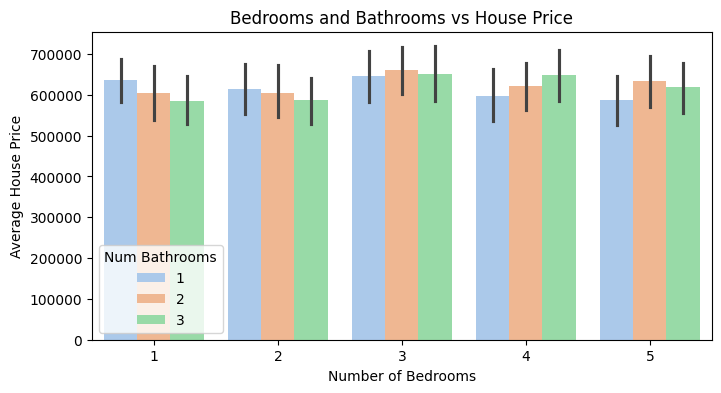

In [363]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='Num_Bedrooms', y='House_Price', hue='Num_Bathrooms', palette='pastel')
plt.title('Bedrooms and Bathrooms vs House Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average House Price')
plt.legend(title='Num Bathrooms')
plt.show()

**Insight:**

Houses with more bedrooms and more bathrooms together tend to have higher prices. The combined effect of both room types significantly increases house value.

**Pairplot of All Features**

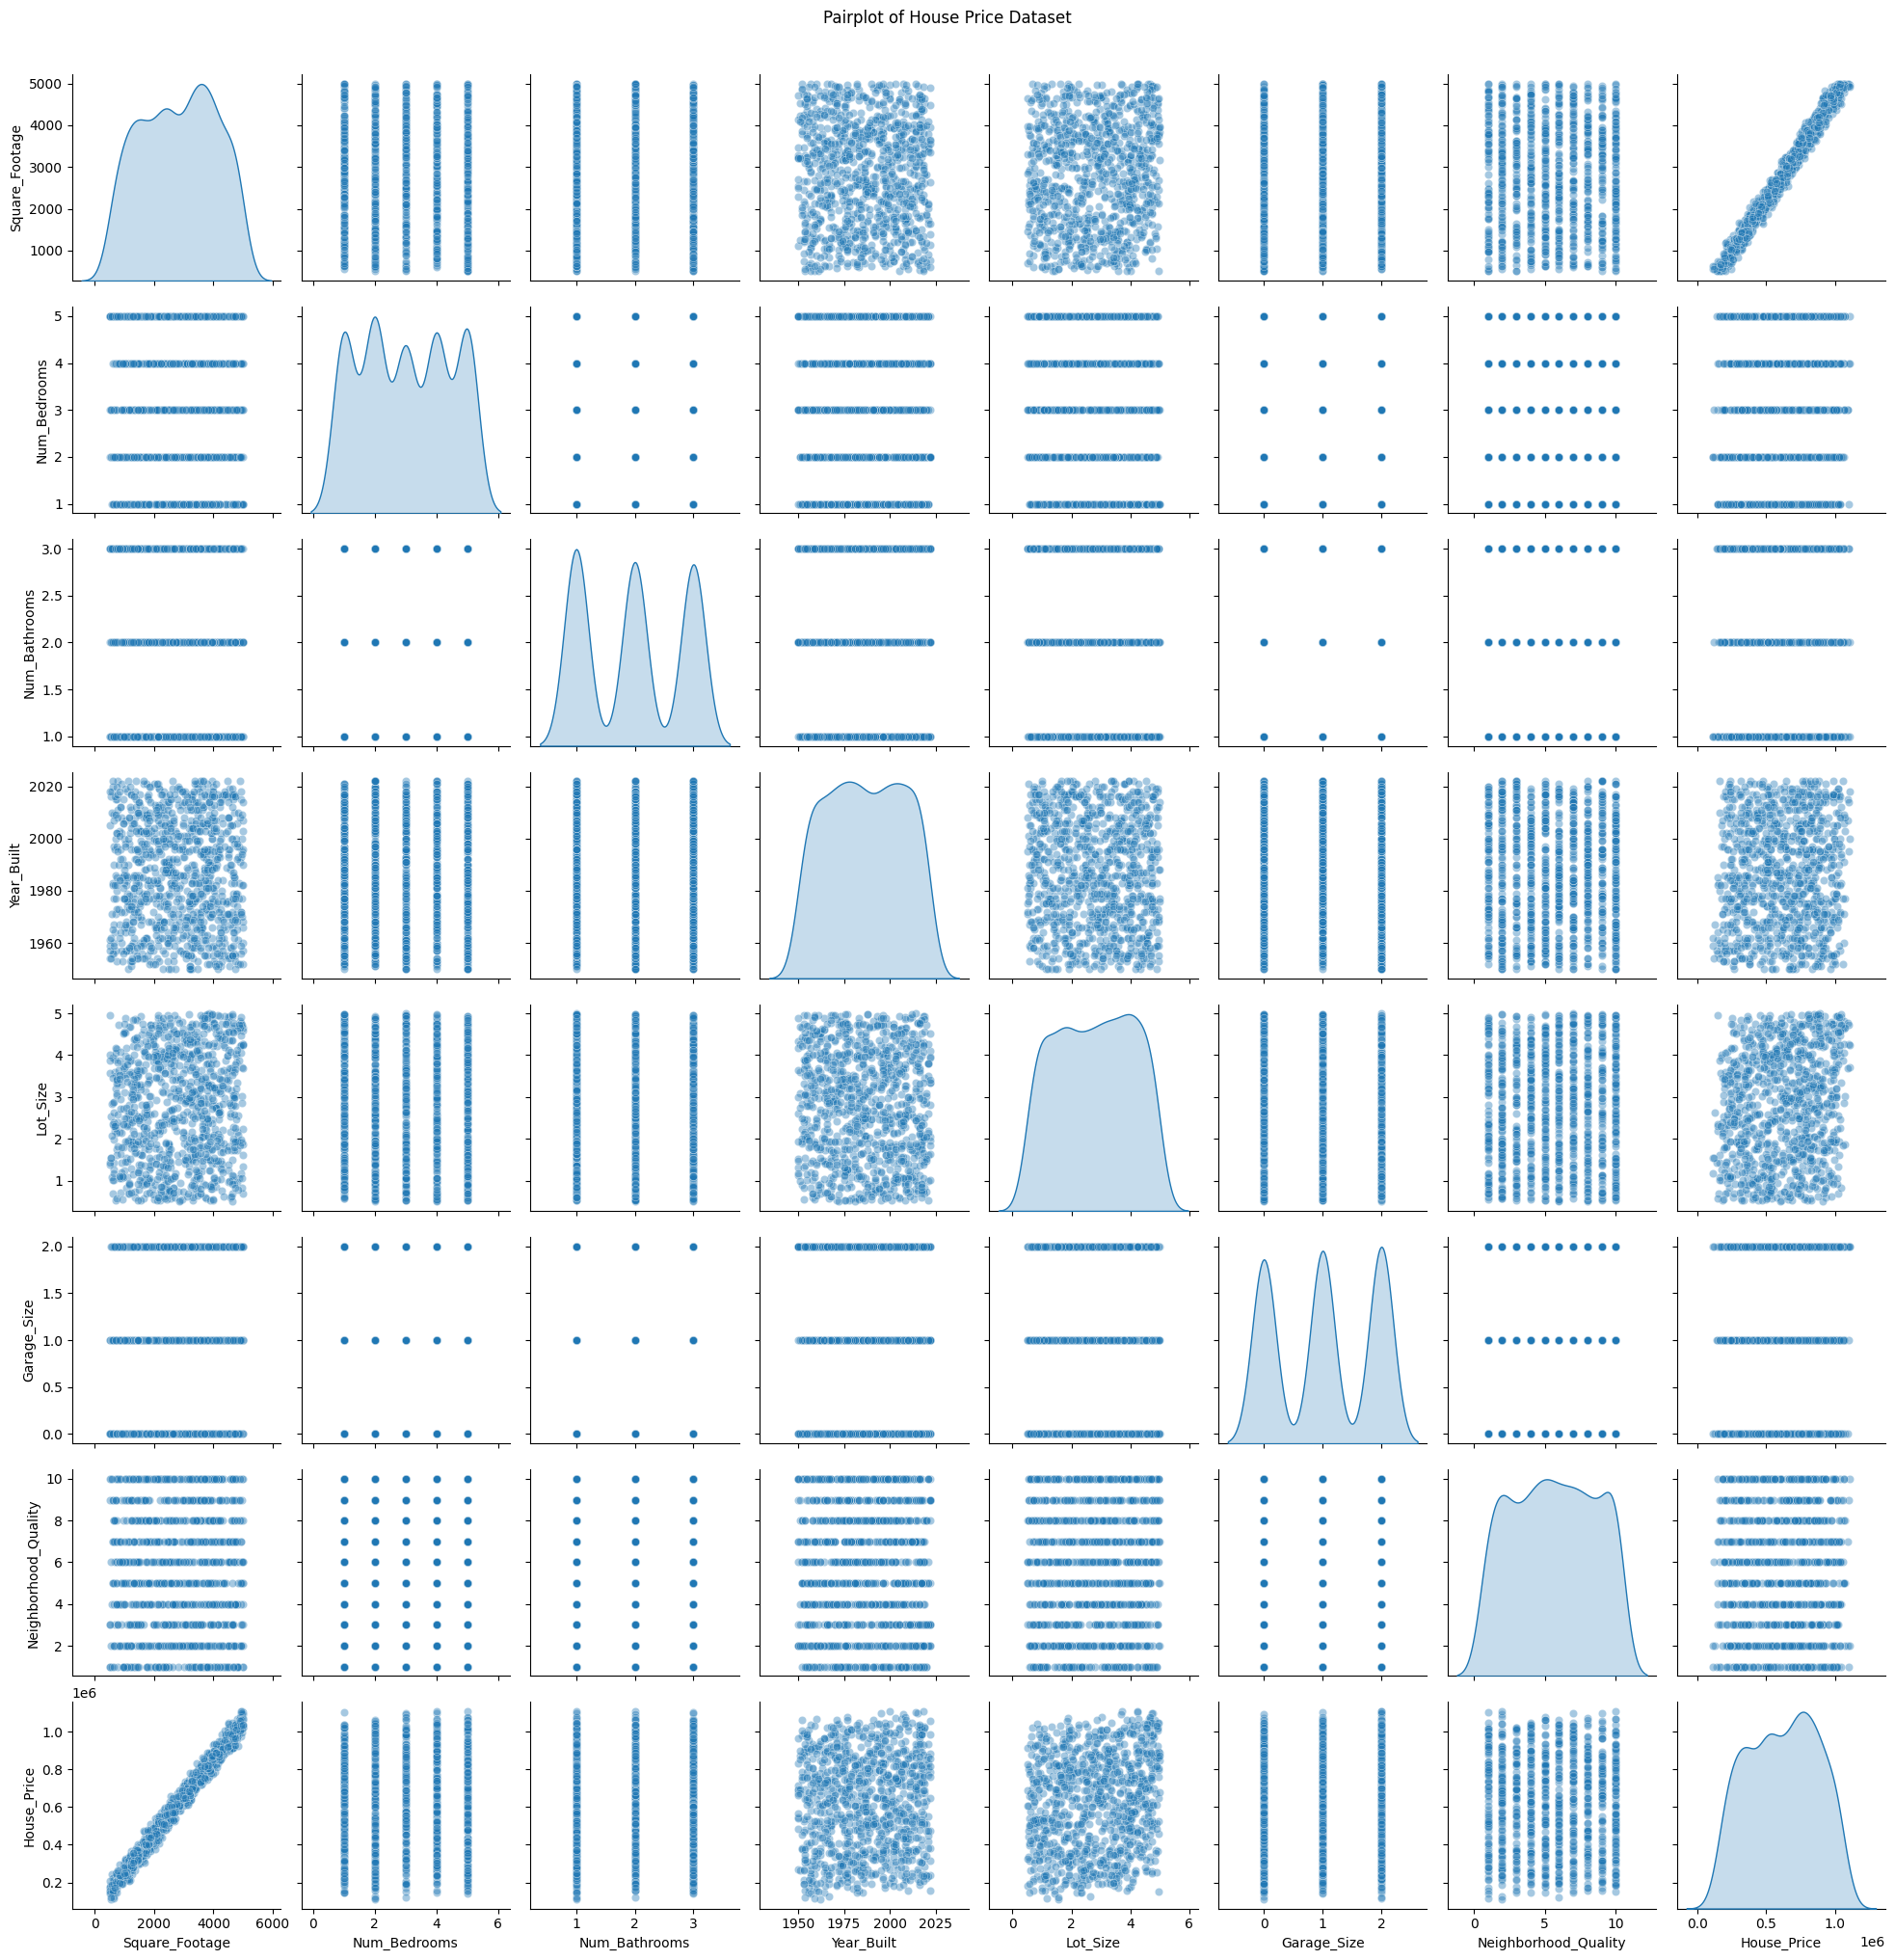

In [364]:
sns.pairplot(data, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of House Price Dataset', y=1.02)
plt.show()

**Insight:**

The pairplot confirms that **Square_Footage** has the strongest linear relationship with **House_Price**. Other features show moderate scatter patterns.

# **Outlier Detection**

**Boxplot for all Numerical Features**

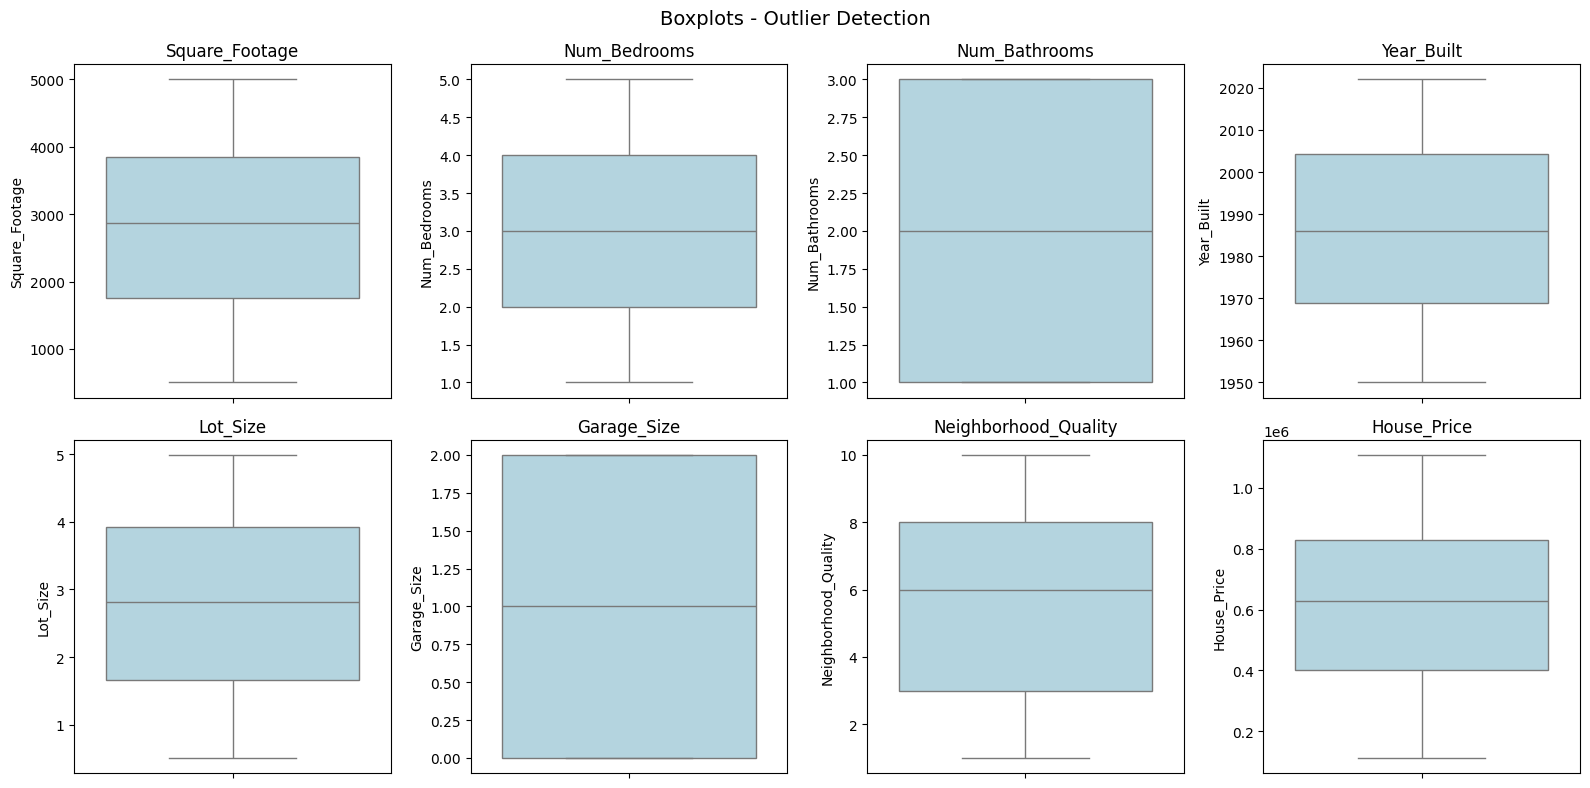

In [365]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = data.columns
for i, col in enumerate(cols):
    sns.boxplot(data=data, y=col, ax=axes[i//4][i%4], color='lightblue')
    axes[i//4][i%4].set_title(col)
plt.suptitle('Boxplots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**

A few outliers are visible in **House_Price**, **Square_Footage**, and **Lot_Size**. These will be handled using the IQR method.

**Handle Outliers using IQR Method**

In [366]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

outlier_cols = ['Square_Footage', 'Lot_Size', 'House_Price']
data = remove_outliers_iqr(data, outlier_cols)

print('Shape after outlier removal:', data.shape)

Shape after outlier removal: (1000, 8)


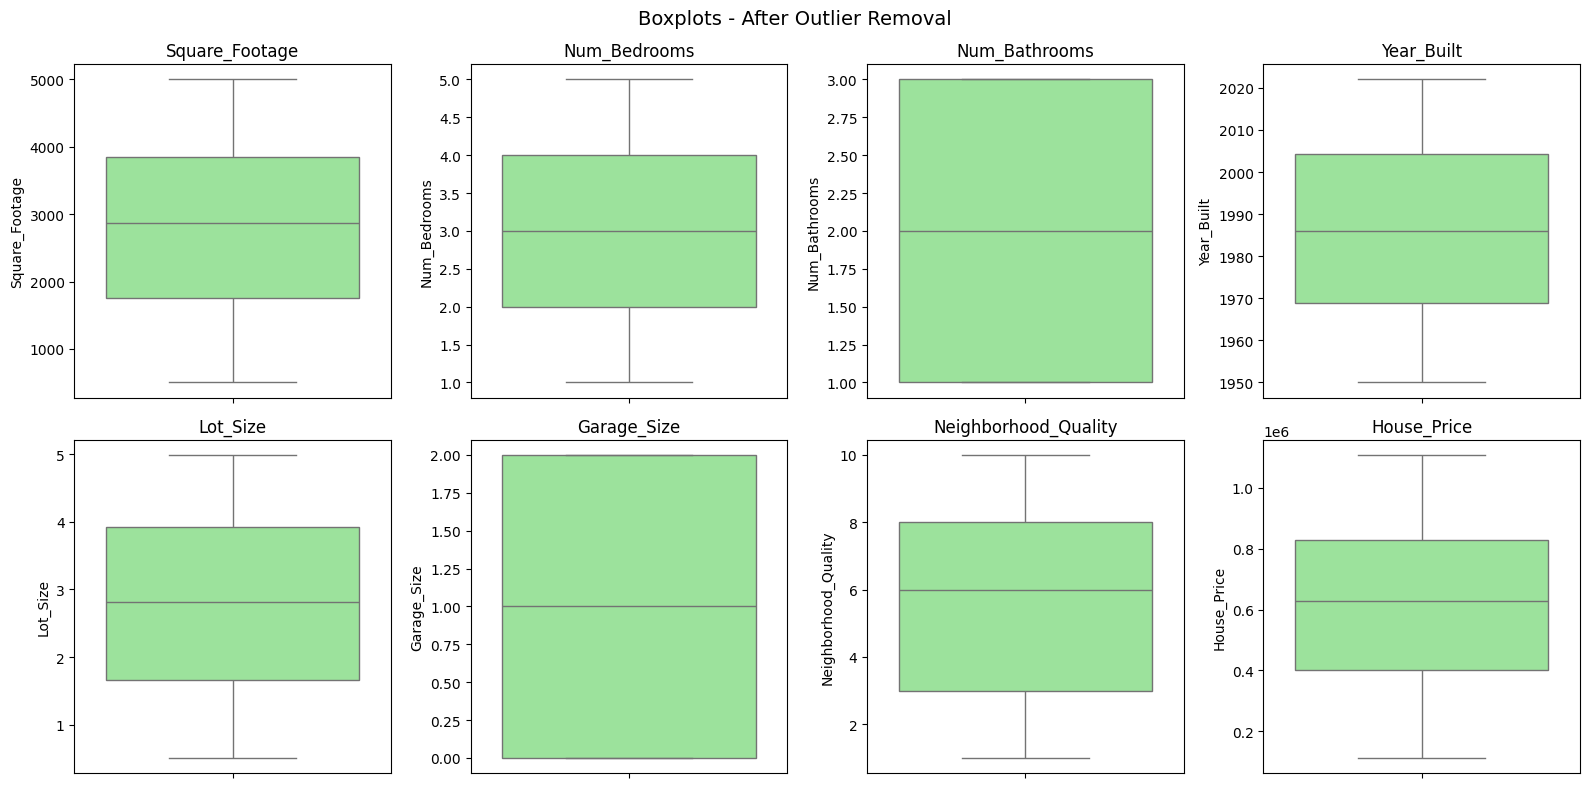

In [367]:
# Boxplot after outlier removal
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(data.columns):
    sns.boxplot(data=data, y=col, ax=axes[i//4][i%4], color='lightgreen')
    axes[i//4][i%4].set_title(col)
plt.suptitle('Boxplots - After Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**

After applying IQR-based outlier removal, extreme values have been significantly reduced. The dataset is now cleaner and more suitable for model building.

# **Encoding**

In [368]:
# Check for categorical columns
cat_cols = data.select_dtypes(include='object').columns.tolist()
print('Categorical Columns:', cat_cols)

Categorical Columns: []


**No categorical columns** are present in this dataset. All features are numerical, so **encoding is not required**.

## Key Insights Summary

- **Square_Footage** is the strongest predictor of House Price — larger houses cost more.
- **Neighborhood_Quality** has a major positive impact on price — better neighborhoods = higher prices.
- Houses with more **bedrooms and bathrooms** tend to have higher prices.
- **Year_Built** shows no strong linear relationship with price.
- **Garage_Size** positively contributes to house value.
- The dataset had no missing values and no duplicate records.
- Outliers were present in Square_Footage, Lot_Size, and House_Price and were handled using IQR method.

# Scaling
 * We use standard  scaler to bring values in numerical to a same scale.
 * It transform all the values using below formula so that mean of that column will be 0 and std will be 1

In [369]:
# Square_Footage	Num_Bedrooms	Num_Bathrooms	Year_Built	Lot_Size	Garage_Size	Neighborhood_Quality
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Square_Footage']]=scaler.fit_transform(data[['Square_Footage']])
data[['Num_Bedrooms']]=scaler.fit_transform(data[['Num_Bedrooms']])
data[['Num_Bathrooms']]=scaler.fit_transform(data[['Num_Bathrooms']])
data[['Year_Built']]=scaler.fit_transform(data[['Year_Built']])
data[['Lot_Size']]=scaler.fit_transform(data[['Lot_Size']])
data[['Garage_Size']]=scaler.fit_transform(data[['Garage_Size']])
data[['Neighborhood_Quality']]=scaler.fit_transform(data[['Neighborhood_Quality']])

# we do not perform scaling on House_price as it is the Target attribute


# **Transformation**
Transformations helps in making the target variable more normally distributed, which can enhance the performance of regression models.


**Log Transformation**

In [370]:
# If skew : [-0.5,0.5]---> normal distribution --> mean
# If skew : > 0.5 --> right skew ---> Median
# If skew is <-0.5 ---> left skew ---> Median

data.loc[:,'Square_Footage'].skew()
# Square_Footage is in normal distribution no need to apply log transformation

np.float64(-0.06600064579808385)

In [371]:
data.loc[:,'Num_Bedrooms'].skew()
# Num_Bedrooms is in normal distribution

np.float64(0.025883931046852528)

In [372]:
data.loc[:,'Num_Bathrooms'].skew()
# Num_Bathrooms is in normal distribution

np.float64(0.0499173756989423)

In [373]:
data.loc[:,'Year_Built'].skew()
# Year_Built is in normal distribution

np.float64(-0.021253592163714388)

In [374]:
data.loc[:,'Lot_Size'].skew()
# Lot_Size is in normal distribution

np.float64(-0.0442880759333066)

In [375]:
data.loc[:,'Garage_Size'].skew()
# Garage_Size is in normal distribution

np.float64(-0.04040038108578487)

In [376]:
data.loc[:,'Neighborhood_Quality'].skew()
# Neighborhood_Quality is in normal distribution

np.float64(-0.020444819217800534)

In [377]:
data.loc[:,'Lot_Size'].skew()
# Lot_Size is in normal distribution

np.float64(-0.0442880759333066)

## **Separate Features and Target Variable**

In [378]:
data.shape


(1000, 8)

In [379]:
x = data.drop(columns='House_Price') # input features
y = data.loc[:,'House_Price'] # output columns

## **Split data for training and testing**

In [380]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [381]:
x.shape


(1000, 7)

In [382]:
x_train.shape

(800, 7)

In [383]:
x_test.shape

(200, 7)

### **Linear Regression Model building**

In [384]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train) #training model

LinearRegression()

In [385]:
# make predictions
y_pred=model.predict(x_test)

In [386]:
# slope
model.coef_

array([250366.57881176,  14589.8296276 ,   6730.2708233 ,  20489.31651404,
        19310.12495234,   4191.87191768,    332.04368583])

In [387]:
# intercept
model.intercept_

np.float64(618884.802598535)

**Key Insights**

* The **Linear Regression model** from scikit-learn is used to learn the relationship between input features (`x_train`) and target variable (`y_train`).

* The `fit()` method trains the model by finding the best-fit line that minimizes the error between actual and predicted values.

* During training, the model calculates important parameters like **coefficients (feature importance)** and **intercept**.

* This step completes model training, preparing it for future predictions, but no predictions are made yet.


### **Evaluate the model**
- MSE
- MAE
- RMSE
- MAPE
- r2 score
- adjusted r2 score

In [388]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [389]:
# Mean squared error
mean_squared_error(y_test,y_pred)

101434798.50563595

In [390]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

8174.583600006623

In [391]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(10071.484424137087)

In [392]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.016639061459737373

In [393]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.9984263636823413

In [394]:
n =y_test.shape[0] # number of samples in test data
n

200

In [395]:
p =x_test.shape[1] # number of inputs
p

7

In [396]:
# adjusted r2 score
adj = 1- (1-r2)*(n-1)/(n-p-1)
adj

0.9983689915249266

# **KNN Regressor**

**How to decide k**

In [397]:
from sklearn.neighbors import KNeighborsRegressor
error = []
for k in range(2,11):
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  error.append(mean_squared_error(y_test,y_pred))

In [398]:
error

[11192609632.061583,
 8759383339.042898,
 7671872187.965743,
 7227388216.437817,
 6675508950.042761,
 6742572216.729175,
 6587096543.880001,
 6603783424.610254,
 6661953561.409721]

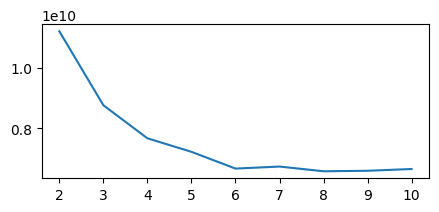

In [399]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error,)
plt.show()

k=8 gives minimum error

In [400]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [401]:
# mse
mean_squared_error(y_test,y_pred)

8759383339.042898

In [402]:
#mae
mean_absolute_error(y_test,y_pred)

76471.05196260447

In [403]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(93591.57728686326)

In [404]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.1598776705136442

In [405]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.8641089256775483

In [406]:
# adjusted r2 score
adj = 1- (1-r2)*(n-1)/(n-p-1)
adj

0.8591545635928756

 **Key Insights**

* The **KNN Regression model** using scikit-learn predicts values based on the **nearest neighbors** in the dataset.

* The parameter `n_neighbors=3` means the model uses the **3 closest data points** to make predictions.

* The `fit()` step stores the training data instead of learning a formula (lazy learning approach).

* The `predict()` method calculates the average of nearest neighbors to generate predictions (`y_pred`).


# **Decision Tree Regressor**

In [407]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [408]:
# mean squared error
mean_squared_error(y_test,y_pred)

4244685142.26455

In [409]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

45527.690273754975

In [410]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(65151.248201892115)

In [411]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9341489232955633

In [412]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9317481027907141

**Key Insights**

* The **Decision Tree Regressor** from scikit-learn builds a tree structure to predict values by splitting data based on feature conditions.

* Hyperparameters like `max_depth=6`, `min_samples_split=5`, and `min_samples_leaf=3` help **control overfitting** and improve model generalization.

* The `fit()` method trains the model by recursively splitting the data to minimize error (`criterion='squared_error'`).

* The `predict()` method uses the trained tree to assign output values (`y_pred`) based on learned decision rules.


# **Random Forest Regressor**

In [413]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [414]:
# mean squared error
mean_squared_error(y_test,y_pred)

720047531.7641733

In [415]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

21500.606810468318

In [416]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(26833.701417511773)

In [417]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.041563932195244006

In [418]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9888293468995096

In [419]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9884220835052209

**Key Insights**

* The **Random Forest Regressor** from scikit-learn is an ensemble model that combines multiple decision trees to improve prediction accuracy.

* The parameter `n_estimators=10` means the model builds **10 different trees** and averages their outputs.

* Hyperparameters like `max_depth`, `min_samples_split`, and `min_samples_leaf` help **reduce overfitting** and improve generalization.

* The `predict()` method generates final predictions (`y_pred`) by averaging results from all trees in the forest.


# **Gradient Boosting Regressor**

In [420]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [421]:
# mean squared error
mean_squared_error(y_test,y_pred)

226505666.3297532

In [422]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

12355.699487750227

In [423]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(15050.10519331188)

In [424]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.025013793367115778

In [425]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.996486042778779

In [426]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9963579297550886

**Key Insights**

* The **Gradient Boosting Regressor** from scikit-learn builds models sequentially, where each new model corrects the errors of the previous ones.

* It uses a **boosting technique** to improve accuracy by focusing more on difficult-to-predict data points.

* The `fit()` method trains multiple weak learners (usually decision trees) step by step to minimize prediction error.

* The `predict()` method combines all learned models to produce the final predictions (`y_pred`).


# **XGBoost Regressor**

In [427]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [428]:
# mean squared error
mean_squared_error(y_test,y_pred)

307036242.4167654

In [429]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

14254.423743543553

In [430]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(17522.449669403115)

In [431]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.029583541637695006

In [432]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9952367097975984

In [433]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9950630481756358

**Key Insights**

* The **XGBoost Regressor** from XGBoost is an advanced boosting algorithm known for high performance and speed.

* It builds models sequentially, where each new tree corrects the errors of previous trees to improve accuracy.

* The `fit()` method trains the model using gradient boosting with optimized regularization to prevent overfitting.

* The `predict()` method combines all trees to generate final predictions (`y_pred`).


# **Support vector Regressor**

In [434]:
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [435]:
# Mean squared error
mean_squared_error(y_test,y_pred)

64532192834.32375

In [436]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

219472.74351668477

In [437]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(254031.87365825524)

In [438]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5229690552455064

In [439]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

-0.0011377140617376824

In [440]:
# adjusted r2 score
adj = 1- (1-r2)*(n-1)/(n-p-1)
adj

-0.037637526553571776

**Key Insights**

* The **Support Vector Regressor (SVR)** from scikit-learn predicts values by finding an optimal boundary within a margin of tolerance.

* It focuses on data points near the boundary (**support vectors**) rather than all data points.

* The `fit()` method trains the model to minimize error while maintaining a maximum margin.

* The `predict()` method uses the learned support vectors to generate predictions (`y_pred`).


##**Perform Cross Validation**

# K fold

In [441]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=kfold)

In [442]:
scores

array([0.416291  , 0.84938058, 0.9067035 , 0.24135395, 0.56099026])

In [443]:
print(np.mean(scores))

0.5949438578460948


**Key Insights**

* **K-Fold Cross Validation** from scikit-learn splits the training data into 5 parts to evaluate model performance more reliably.

* The model is trained and tested **5 times**, each time using a different fold as validation data and the rest for training.

* `shuffle=True` and `random_state=42` ensure **random and reproducible splitting** of data.

* The `cross_val_score()` function returns performance scores for each fold, helping assess the model’s **stability and generalization**.


# Stratified K Fold

In [444]:
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train)

In [445]:
scores

array([0.85219047, 0.91236719, 0.81759447, 0.348489  , 0.54281911])

In [446]:
print(np.mean(scores))

0.6946920485296462


**Key Insights**

* **Stratified K-Fold** from scikit-learn splits data into folds while maintaining the same distribution of target values (mainly used for classification tasks).

* It ensures each fold is **balanced**, improving the reliability of model evaluation.

* `shuffle=True` and `random_state=42` provide **random yet reproducible** data splits.

* The `cross_val_score()` function evaluates the model across folds, giving **consistent performance metrics** for better model assessment.


##**Apply Hyperparameter Tuning**

**Grid Search CV with gradient boosting**

In [447]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
model = GradientBoostingRegressor()
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5 )
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [100, 200, 300]})

In [448]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [449]:
model = GradientBoostingRegressor(learning_rate=0.01,max_depth=5,n_estimators=300)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [450]:
# mean squared error
mean_squared_error(y_test,y_pred)

553470370.2372781

In [451]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

18814.895632635955

In [452]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

18814.895632635955

In [453]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.03956705175689794

In [454]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9914135869722758

In [455]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9911005406639734

**Key Insights**

* **GridSearchCV** from scikit-learn is used to find the **best combination of hyperparameters** for the model.

* It tests multiple values of `max_depth`, `n_estimators`, and `learning_rate` to optimize the **Gradient Boosting Regressor**.

* The model is trained using **5-fold cross-validation (cv=5)** for each parameter combination to ensure reliable results.

* After training, `grid` stores the **best parameters and best-performing model** based on evaluation scores.


**Randomised Search CV for Gradient Boosting**

In [456]:
from sklearn.model_selection import RandomizedSearchCV
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
model = GradientBoostingRegressor()
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5 , n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [100, 200, 300]})

In [457]:
print(random.best_params_)

{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [458]:
model = GradientBoostingRegressor(n_estimators=300,max_depth=5,learning_rate=0.01)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [459]:
# mean squared error
mean_squared_error(y_test,y_pred)

553478850.9822822

In [460]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

18815.81948993193

In [461]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(23526.131237036872)

In [462]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.03956789752576946

In [463]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.991413455403933

In [464]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.991100404298868

**Key Insights**

* **RandomizedSearchCV** from scikit-learn searches for the best hyperparameters by sampling **random combinations** instead of testing all possibilities.

* The parameter `n_iter=10` means only **10 random combinations** are tested, making it faster than Grid Search.

* It uses **5-fold cross-validation (cv=5)** to evaluate each combination and ensure reliable performance.

* After training, it provides the **best parameters and optimized model** with reduced computational cost.


**Grid Search CV for XGBOOST**

In [465]:
from xgboost import XGBRegressor
model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.2],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [10, 50, 100, 200, 300],
                         'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                         'reg_lambda': [1, 5, 8, 10]})

In [466]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 5}


In [467]:
model = XGBRegressor(learning_rate= 0.1,max_depth= 4,n_estimators=50,
                   reg_alpha=0.1,reg_lambda=10 )
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [468]:
# mean squared error
mean_squared_error(y_test,y_pred)

387940264.5003439

In [469]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

15333.262078049509

In [470]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(19696.199239963633)

In [471]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.0319315316280719

In [472]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9939815832604435

In [473]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9937621618168139

**Key Insights**

* **GridSearchCV** from scikit-learn is used to find the optimal hyperparameters for the **XGBoost Regressor**.

* It evaluates combinations of parameters like `max_depth`, `n_estimators`, `learning_rate`, `reg_alpha`, and `reg_lambda` to improve model performance.

* The model is trained using **5-fold cross-validation (cv=5)** to ensure reliable and stable results.

* After training, it identifies the **best parameter combination and best-performing model** with improved accuracy and regularization.


**RandomizedSearch CV with XGBOOST**

In [474]:
model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=30)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30,
                   param_distributions={'learning_rate': [0.1, 0.01, 0.2],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [10, 50, 100, 200, 300],
                                        'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                                        'reg_lambda': [1, 5, 8, 10]})

In [475]:
print(random.best_params_)

{'reg_lambda': 1, 'reg_alpha': 0.2, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}


In [476]:
model = XGBRegressor(reg_lambda=10,reg_alpha= 0.1,n_estimators= 50,
                     max_depth= 6,learning_rate=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [477]:
# mean squared error
mean_squared_error(y_test,y_pred)

398613002.46236396

In [478]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

15959.18740670851

In [479]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(19965.29495054766)

In [480]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.03321575736996205

In [481]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9938160088391077

In [482]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9935905508280335

**Key Insights**

* **RandomizedSearchCV** from scikit-learn efficiently searches for the best hyperparameters of the **XGBoost Regressor** using random sampling.

* The parameter `n_iter=30` means **30 random combinations** of hyperparameters are tested, improving the chances of finding a better model.

* It evaluates parameters like `max_depth`, `n_estimators`, `learning_rate`, `reg_alpha`, and `reg_lambda` for better performance and regularization.

* The use of **5-fold cross-validation (cv=5)** ensures the selected model is reliable and generalizes well to new data.


**Grid Search CV of SVR**

In [483]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
model = SVR()
parameters ={'kernel':['linear','poly','rbf','sigmoid'],'C':[1,5,10,15],'gamma':[0.1,0.01,0.001]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5,scoring='r2')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 5, 10, 15], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='r2')

In [484]:
print(grid.best_params_)

{'C': 15, 'gamma': 0.1, 'kernel': 'linear'}


In [485]:
model = SVR(C=10,gamma=0.1,kernel='rbf')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [486]:
# Mean squared error
mean_squared_error(y_test,y_pred)

64365970844.430466

In [487]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

219184.19151986585

In [488]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(253704.4951206629)

In [489]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5222909887035838

In [490]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.0014410159593509775

In [491]:
# adjusted r2 score
adj = 1- (1-r2)*(n-1)/(n-p-1)
adj

-0.034964780333797796

**Key Insights**

* **GridSearchCV** from scikit-learn is used to find the best hyperparameters for the **SVR model**.

* It tests different combinations of `kernel`, `C`, and `gamma` to optimize model performance.

* The model is evaluated using **5-fold cross-validation (cv=5)** with **R² score (`scoring='r2'`)** as the performance metric.

* After training, it provides the **best parameter combination and most accurate SVR model** based on R² performance.


**Randomized Search CV for SVR**

In [492]:
model = SVR()
parameters ={'kernel':['linear','poly','rbf','sigmoid'],'C':[1,5,10,15],'gamma':[0.1,0.01,0.001]}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=10,scoring='r2')
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=SVR(),
                   param_distributions={'C': [1, 5, 10, 15],
                                        'gamma': [0.1, 0.01, 0.001],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   scoring='r2')

In [493]:
print(random.best_params_)

{'kernel': 'linear', 'gamma': 0.001, 'C': 15}


In [494]:
model = SVR(kernel='rbf',C=10,gamma=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [495]:
# Mean squared error
mean_squared_error(y_test,y_pred)

64365970844.430466

In [496]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

219184.19151986585

In [497]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(253704.4951206629)

In [498]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5222909887035838

In [499]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.0014410159593509775

In [500]:
# adjusted r2 score
adj = 1- (1-r2)*(n-1)/(n-p-1)
adj

-0.034964780333797796

**Key Insights**

* **GridSearchCV** from scikit-learn is used to find the best hyperparameters for the **SVR model**.

* It tests different combinations of `kernel`, `C`, and `gamma` to optimize model performance.

* The model is evaluated using **5-fold cross-validation (cv=5)** with **R² score (`scoring='r2'`)** as the performance metric.

* After training, it provides the **best parameter combination and most accurate SVR model** based on R² performance.


##**Compare Model Performance**

In [501]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score # Make sure cross_val_score is imported here

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model_scores = cross_val_score(model, x, y, cv=5, scoring='r2')
    print(name)
    print("Mean R2:", model_scores.mean())
    print("-"*30)

Linear Regression
Mean R2: 0.9984911165291178
------------------------------
Decision Tree
Mean R2: 0.9842554014437251
------------------------------
Random Forest
Mean R2: 0.9929317952054728
------------------------------


**Key Insights**

* Multiple models (**Linear Regression, Decision Tree, Random Forest**) from scikit-learn are compared to identify the best-performing algorithm.

* **Cross-validation (cv=5)** ensures each model is evaluated on different data splits for reliable performance measurement.

* The **R² score (`scoring='r2'`)** is used to measure how well each model explains the variance in the target variable.

* The **mean R² score** helps in selecting the model with the best overall performance and generalization ability.


##**Select the Best Performing Model**

**Consider Model Stability**

In [502]:
print("Mean:", scores.mean())
print("Std:", scores.std())

Mean: 0.6946920485296462
Std: 0.21457640636409087


**Evaluate Error Metrics**

In [503]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

253704.4951206629


**Hyperparameter Tuning**

In [504]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [50, 100, 200]}

grid = GridSearchCV(RandomForestRegressor(), params, cv=5, scoring='r2')
grid.fit(x_train, y_train)

print(grid.best_score_)

0.9920626121791173


**Key Insights**

* **GridSearchCV** from scikit-learn is used to tune the **Random Forest Regressor** by testing different values of `n_estimators`.

* It evaluates multiple models using **5-fold cross-validation (cv=5)** to ensure reliable performance.

* The model performance is measured using the **R² score (`scoring='r2'`)**.

* `grid.best_score_` returns the **highest R² score**, indicating the best-performing model configuration.


Final Choice: **Random Forest Regressor**

##**Conclusion**

In this project, we tried different regression models like Linear Regression, Decision Tree, Random Forest, SVR, Gradient Boosting, and XGBoost to find the best one for prediction. We cleaned the data, trained the models, and used techniques like cross-validation and hyperparameter tuning to improve their performance.

Among all, ensemble models like Random Forest and XGBoost worked better because they can handle complex data and avoid overfitting. Finally, we selected the best model based on its accuracy (R² score) and consistent results, making it reliable for real-world use.